# Example-22: Unstable initials coloring

In [1]:
# In this example, time-indicator construction is illustrated
# Normally, given a maximum number of iterations, only the initial conditions that remain stable throughout all iterations are colored
# To color all initial conditions, it is possible to use the escape time
# A chaos indicator can also be used by applying a threshold instead of checking whether the initial condition remains within a certain domain

In [2]:
# Import

import numpy

from tqdm import tqdm

import jax
from jax import jit
from jax import vmap

# Test symplectic mapping and corresponding inverse

from tohubohu.util import forward4D
from tohubohu.util import inverse4D

# Scanning

from tohubohu.scan import iterate
from tohubohu.scan import count
from tohubohu.scan import orbit
from tohubohu.scan import final
from tohubohu.scan import scan

# Dynamic aperture

from tohubohu.da import directions
from tohubohu.da import da
from tohubohu.da import refine

# GALI factory

from tohubohu import gali
from tohubohu.gali import counter

# Plotting

from matplotlib import pyplot as plt
from matplotlib import colormaps

cmap = colormaps.get_cmap('turbo_r')
cmap.set_bad(color='lightgray')

In [3]:
# Set data type

jax.config.update("jax_enable_x64", True)

In [4]:
# Set device

device, *_ = jax.devices('cpu')
jax.config.update('jax_default_device', device)

In [5]:
# Set mapping parameters

nux, nuy = 0.168, 0.201
mux, muy = 2*jax.numpy.pi*nux, 2*jax.numpy.pi*nuy
cx, sx, cy, sy = jax.numpy.cos(mux), jax.numpy.sin(mux), jax.numpy.cos(muy), jax.numpy.sin(muy)
mu = 0.0

k = jax.numpy.asarray([cx, sx, cy, sy, mu])

In [6]:
# Scan (iterate)

length = 2**10
radius = 5.0
fn = jit(iterate(length, radius, forward4D))

x = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
print(fn(x, k))

x = jax.numpy.array([0.8, 0.0, 0.0, 0.0])
print(fn(x, k))

True
False


In [7]:
# Scan (count)

length = 2**10
radius = 5.0
fn = jit(count(length, radius, forward4D))

x = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
print(fn(x, k))

x = jax.numpy.array([0.8, 0.0, 0.0, 0.0])
print(fn(x, k))

1024
152


In [8]:
# Scan (orbit)

length = 2**10
radius = 5.0
fn = jit(orbit(length, radius, forward4D))

x = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
print(fn(x, k).shape)

(1024, 4)


In [9]:
# Scan (final)

length = 2**10
radius = 5.0
fn = jit(final(length, forward4D))

x = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
print(fn(x, k).shape)

(4,)


In [10]:
# Scan (scan)

length = 2**10
radius = 5.0
fn = count(2**10, radius, forward4D)

xs = jax.numpy.array([[0.0, 0.0, 0.0, 0.0], [0.8, 0.0, 0.0, 0.0]])
print(scan(xs, fn, k))
print(jit(vmap(fn, (0, None)))(xs, k))

[1024  152]
[1024  152]


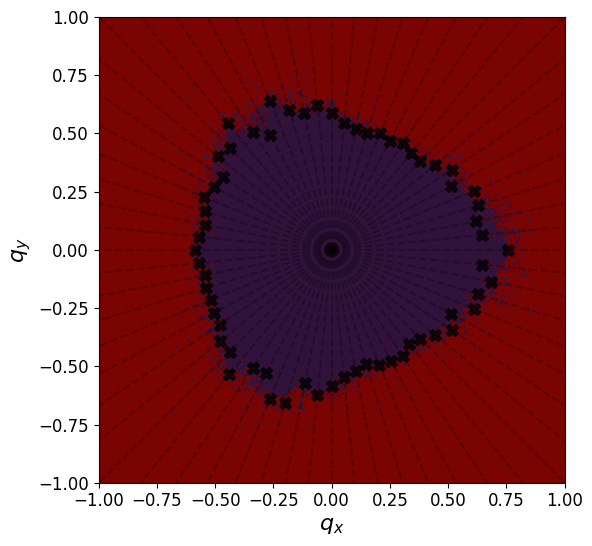

In [11]:
# Survival grid DA and ray-based DA

n = 1001

qx = jax.numpy.linspace(-1.0, 1.0, n)
qy = jax.numpy.linspace(-1.0, 1.0, n)
qxqy = jax.numpy.stack(jax.numpy.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = jax.numpy.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = jax.numpy.stack([qx, qy, px, py]).T

length = 2**10
radius = 5.0
generator = jit(iterate(length, radius, forward4D))

mask = scan(xs, generator, k)

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(mask.reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-1.0, 1.0, -1.0, 1.0))

ds = directions(4, 64, random=False, ij=(0, 1), omega_min=0.0, omega_max=2.0*jax.numpy.pi)
qxs, qys, *_ = ds.T
for qx, qy in zip(qxs, qys):
    plt.plot([0.0, 2*qx], [0.0, 2*qy], linestyle='dashed', color='black', alpha=0.25)


dr = 0.01
origin = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
rs, xs = da(dr, radius, origin, ds, generator, k)
rs, xs = refine(dr, radius, origin, ds, 8, rs, generator, k)
qxs, qys, *_ = xs.T

plt.errorbar(qxs, qys, fmt=' ', marker='X', color='black', ms=8, alpha=0.75)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$q_y$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

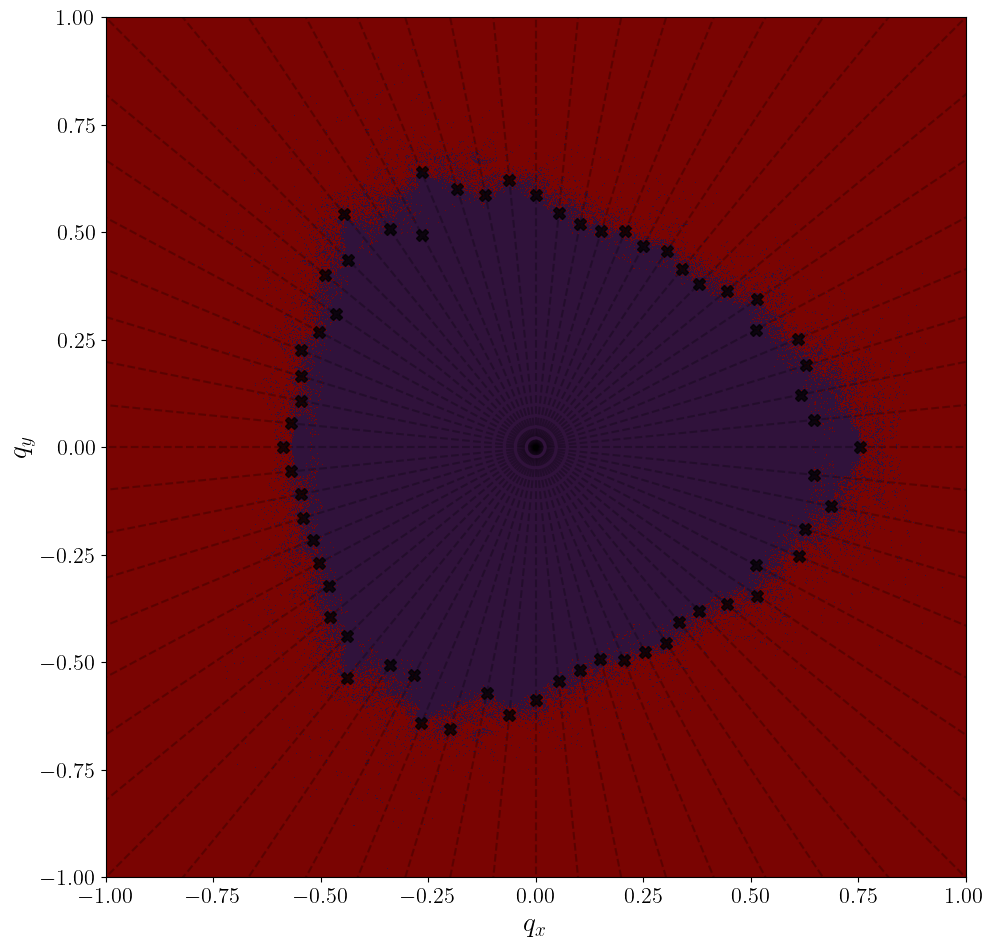

In [17]:
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import colormaps

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(mask.reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-1.0, 1.0, -1.0, 1.0))

ds = directions(4, 64, random=False, ij=(0, 1), omega_min=0.0, omega_max=2.0*jax.numpy.pi)
qxs, qys, *_ = ds.T
for qx, qy in zip(qxs, qys):
    plt.plot([0.0, 2*qx], [0.0, 2*qy], linestyle='dashed', color='black', alpha=0.25)


dr = 0.01
origin = jax.numpy.array([0.0, 0.0, 0.0, 0.0])
rs, xs = da(dr, radius, origin, ds, generator, k)
rs, xs = refine(dr, radius, origin, ds, 8, rs, generator, k)
qxs, qys, *_ = xs.T

plt.errorbar(qxs, qys, fmt=' ', marker='X', color='black', ms=8, alpha=0.75)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(r"$q_x$", fontsize=20)
plt.ylabel(r"$q_y$", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('rays.png')
plt.tight_layout()
plt.show()

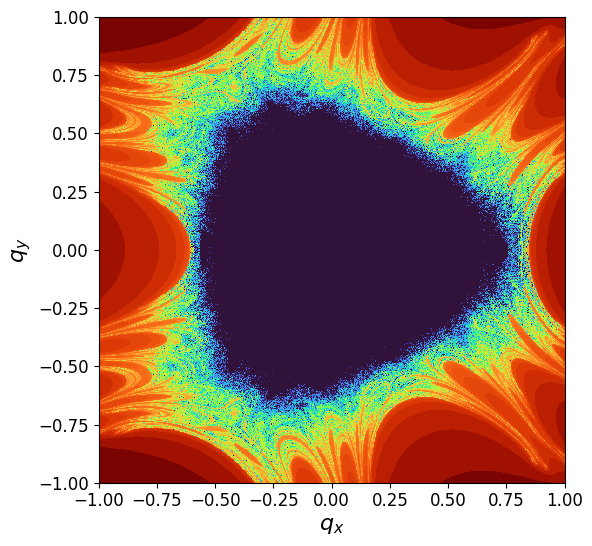

In [12]:
# The above plot shows what is practically called the dynamic aperture -- a stable region for a given number of iterations
# Grid-based computation provides more detail on the shape, while ray-based computation is much more computationally efficient
# In both cases, the internal structure of the region remains unexplored (this can be studied using chaos indicators)
# Similarly, the external region of unstable initial conditions is not explored in detail
# The simplest way to explore unstable points is to count the number of iterations for which they remain bounded

n = 1001

qx = jax.numpy.linspace(-1.0, 1.0, n)
qy = jax.numpy.linspace(-1.0, 1.0, n)
qxqy = jax.numpy.stack(jax.numpy.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
pxpy = jax.numpy.full_like(qxqy, 0.0)
qx, qy = qxqy.T
px, py = pxpy.T
xs = jax.numpy.stack([qx, qy, px, py]).T

length = 2**10
radius = 5.0
generator = jit(count(length, radius, forward4D))

mask = scan(xs, generator, k)

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + mask).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-1.0, 1.0, -1.0, 1.0))
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$q_y$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

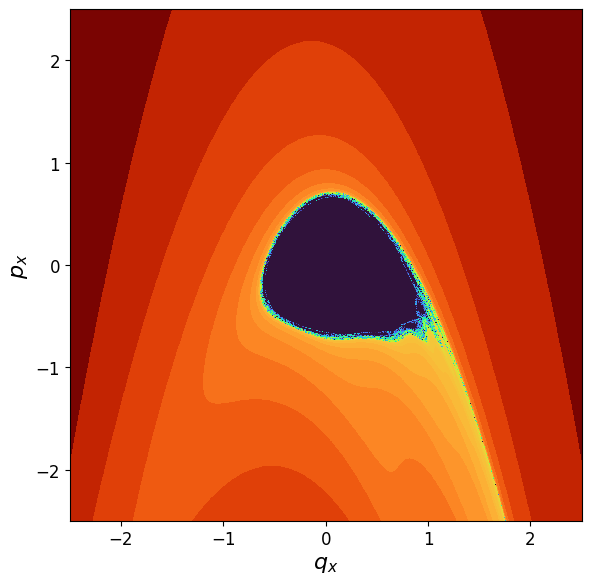

In [13]:
# The result for qx-px plane shows that the outside region is somehow shaped by hyperbolic manifolds
# And the survival plot seems to color only a part of the structure

n = 2001
qx = jax.numpy.linspace(-2.5, 2.5, n)
px = jax.numpy.linspace(-2.5, 2.5, n)
qxpx = jax.numpy.stack(jax.numpy.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = jax.numpy.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = jax.numpy.stack([qx, qy, px, py]).T

length = 2**10
radius = 5.0
generator = jit(count(length, radius, forward4D))

mask_forward = scan(xs, generator, k)

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + mask_forward).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

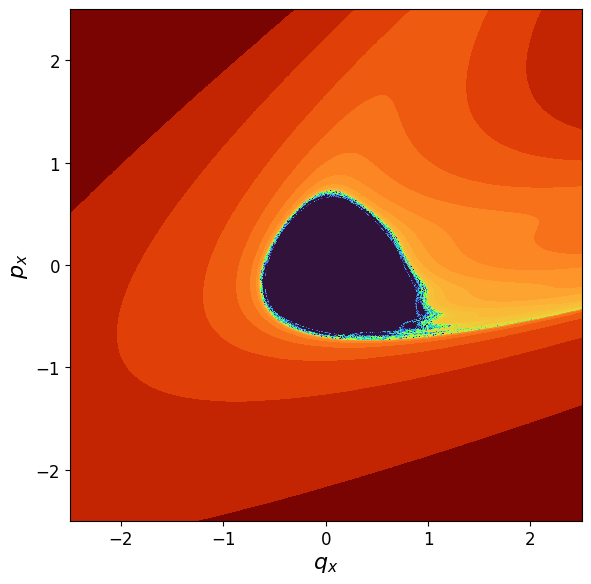

In [14]:
# Using inverse mapping, we can explore the other part

n = 2001
qx = jax.numpy.linspace(-2.5, 2.5, n)
px = jax.numpy.linspace(-2.5, 2.5, n)
qxpx = jax.numpy.stack(jax.numpy.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = jax.numpy.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = jax.numpy.stack([qx, qy, px, py]).T

length = 2**10
radius = 5.0
generator = jit(count(length, radius, inverse4D))

mask_inverse = scan(xs, generator, k)

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + mask_inverse).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

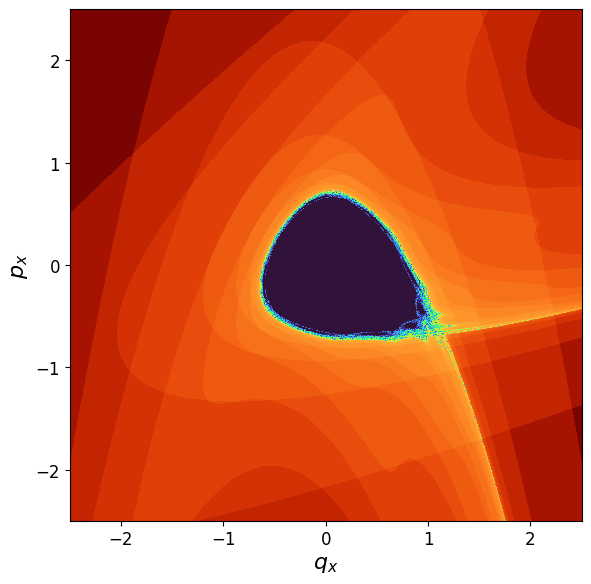

In [15]:
# The above plots are related to escape speed, which is slow for forward mapping on stable manifold and slow for inverse mapping on unstable manifold
# And the results can be combined to display fast regions without

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + 0.5*(mask_forward + mask_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

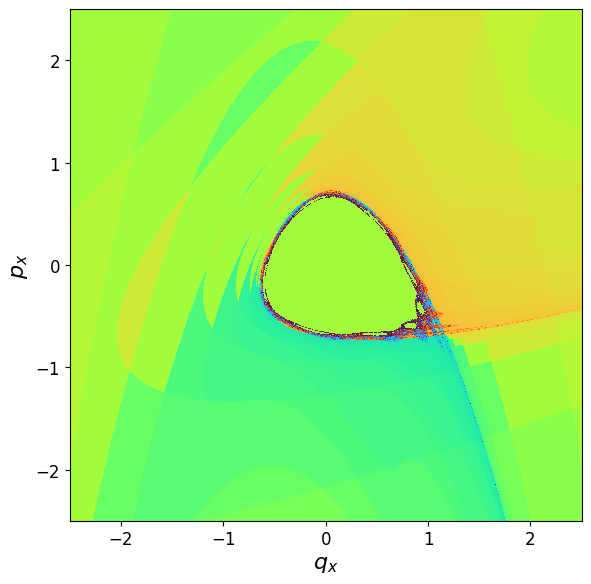

In [16]:
# Or with direction

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow((jax.numpy.sign(mask_forward - mask_inverse)*jax.numpy.log10(1 + 0.5*(mask_forward + mask_inverse))).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

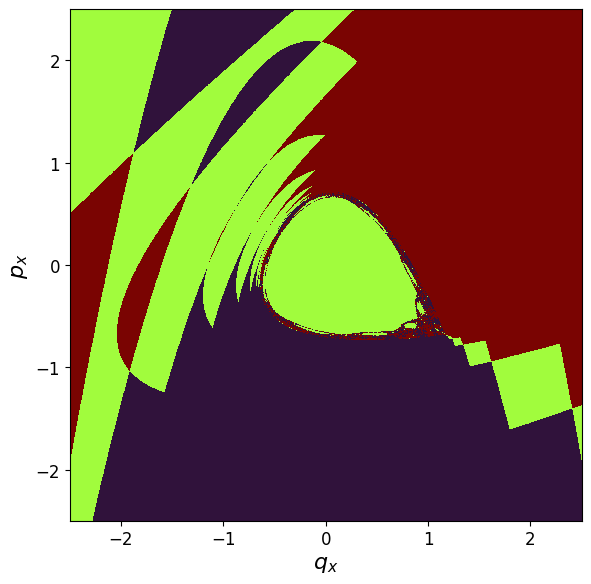

In [17]:
# Or one can plot just the sign

fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow((jax.numpy.sign(mask_forward - mask_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# In contrast to chaos indicators, survival time colors the exterior of the finite stable region
# It is, however, also possible to use a chaos indicator as an iteration-stopping criterion
# Consider an indicator that either decreases or increases, but at different rates for regular and chaotic initial conditions
# One can then use the time required to reach a given indicator level as an indicator in its own right

In [19]:
# By default GALI indicator returns only the indicator computed using deviation vectors at the final point

x = jax.numpy.array([0.25, 0.25, 0.0, 0.0])
vs = jax.numpy.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]])

fn = jit(gali(length, forward4D))

print(fn(x, vs, k))

0.001674598762327535


In [20]:
# It is also possible to return the full output so that it can be passed again
# This can be used to compute the GALI indicator at each iteration, but using an explicit loop is not efficient

x = jax.numpy.array([0.25, 0.25, 0.0, 0.0])
vs = jax.numpy.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]])

fn = jit(gali(1, forward4D, full=True))

for _ in range(length):
    result, x, vs, = fn(x, vs, k)

print(result)

0.001674598762327535


In [21]:
# If only the time to reach a threshold is required, the following function can be used

x = jax.numpy.array([0.25, 0.25, 0.0, 0.0])
vs = jax.numpy.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]])

fn = jit(count(length, radius, forward4D))
print(fn(x, k))

level = 1.0E-3
fn = jit(counter(length, level, forward4D))
print(fn(x, vs, k))

1024
255


In [22]:
n = 2001

qx = jax.numpy.linspace(-2.5, 2.5, n)
px = jax.numpy.linspace(-2.5, 2.5, n)
qxpx = jax.numpy.stack(jax.numpy.meshgrid(qx, px, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
qypy = jax.numpy.full_like(qxpx, 0.0)
qx, px = qxpx.T
qy, py = qypy.T
xs = jax.numpy.stack([qx, qy, px, py]).T
xs = jax.numpy.array_split(xs, n)
vs = jax.numpy.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 1.0]])

length = 2**10
level = 1.0E-9

forward = jit(vmap(counter(length, level, forward4D), (0, None, None)))
inverse = jit(vmap(counter(length, level, inverse4D), (0, None, None)))

xb, *xr = xs

mask_forward = [forward(xb, vs, k)]
mask_inverse = [inverse(xb, vs, k)]

for xb in tqdm(xr):
    mask_forward.append(forward(xb, vs, k))
    mask_inverse.append(inverse(xb, vs, k))

mask_forward = jax.numpy.concatenate(mask_forward)
mask_inverse = jax.numpy.concatenate(mask_inverse)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [2:52:00<00:00,  5.16s/it]


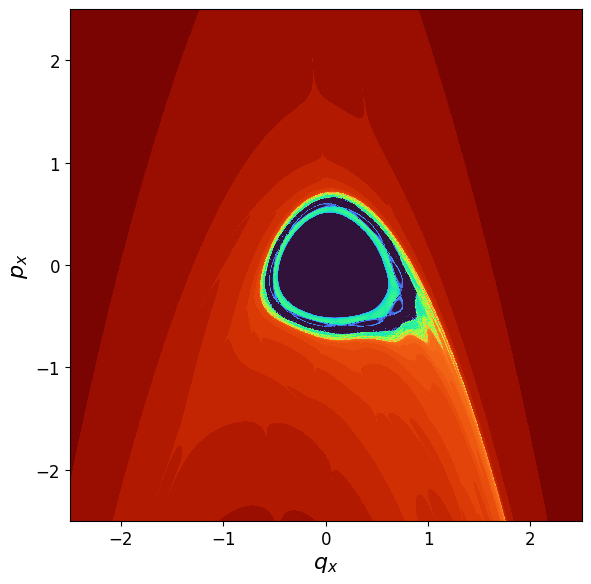

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + mask_forward).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

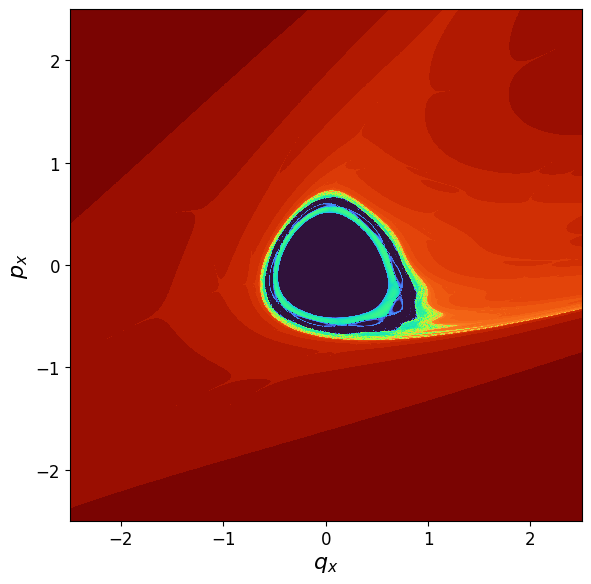

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + mask_inverse).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

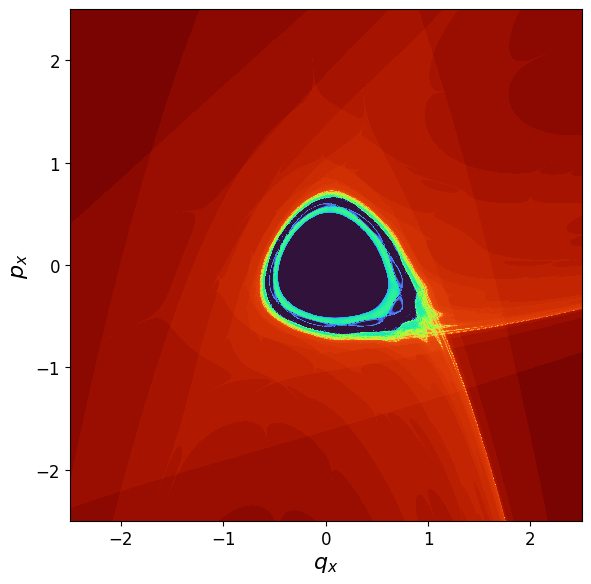

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(jax.numpy.log10(1 + 0.5*(mask_forward + mask_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

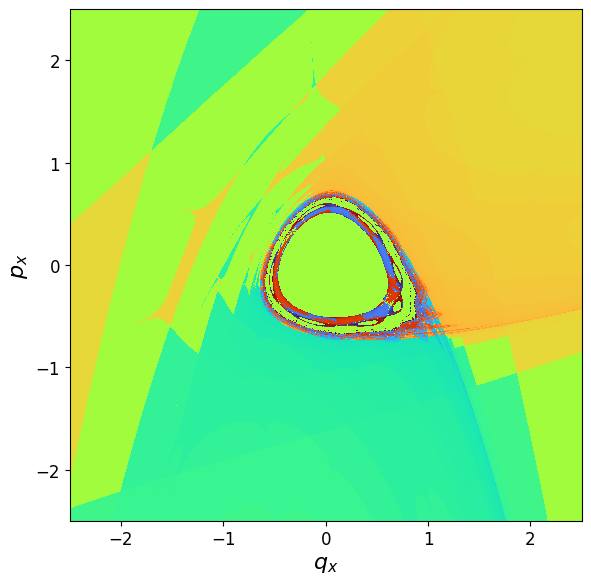

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow((jax.numpy.sign(mask_forward - mask_inverse)*jax.numpy.log10(1 + 0.5*(mask_forward + mask_inverse))).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

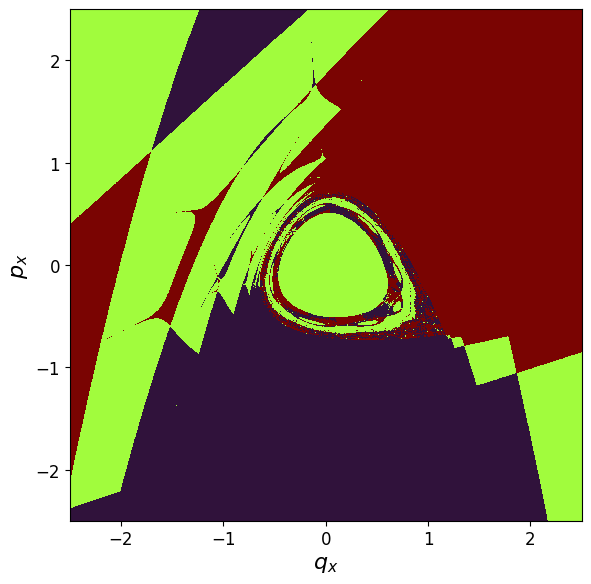

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow((jax.numpy.sign(mask_forward - mask_inverse)).reshape(n, n), aspect='equal', origin='lower', cmap=cmap, interpolation='nearest', extent=(-2.5, 2.5, -2.5, 2.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.xlabel(r"$q_x$", fontsize=16)
plt.ylabel(r"$p_x$", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()